# Обработка фото рисунка

In [80]:
%load_ext autoreload
%autoreload 2

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from utils import (
    detect_and_align, alignment_error, extract_colored,
    transfer_color, correct_photo, template_meta,
    image_rect_from_svg,
    build_triangulation, draw_triangulation,
    animate_character,
)

# --- конфиг персонажа ---
CHAR_ID = "003"
CHAR_DIR = f"templates/{CHAR_ID}"

SVG_PATH = f"{CHAR_DIR}/mask.svg"
TEMPLATE_SKELETON_PATH = f"{CHAR_DIR}/skeleton.json"
MOTION_PATH = f"{CHAR_DIR}/animation.json"

# --- конфиг фото ---
PHOTO_PATH = f"input/{CHAR_ID}_test4.jpg"
CONTENT_SCALE = 0.8

CANVAS_SIZE = (1240, 1754)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)

# image_rect прямо из SVG (без PNG)
image_rect = image_rect_from_svg(
    SVG_PATH, content_scale=CONTENT_SCALE,
    canvas_size=CANVAS_SIZE, marker_px=MARKER_PX,
    margin=MARGIN, content_pad=CONTENT_PAD,
)
print(f"image_rect: {image_rect}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
image_rect: [345, 244, 1064, 752]


## Шаг 1. Выравнивание по ArUco

Ошибка выравнивания: 4.16 px


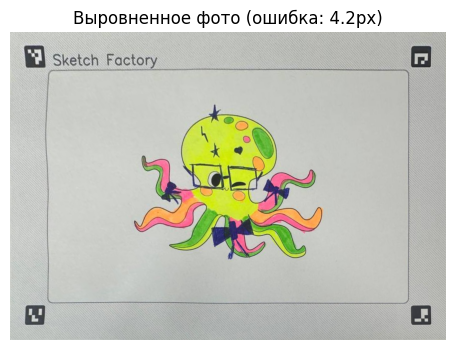

In [81]:
result = detect_and_align(PHOTO_PATH, meta)
aligned = result["aligned"]

mean_err, _ = alignment_error(aligned, meta)
print(f"Ошибка выравнивания: {mean_err:.2f} px")

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Выровненное фото (ошибка: {mean_err:.1f}px)")
plt.show()

## Шаг 3. Вырезка рисунка


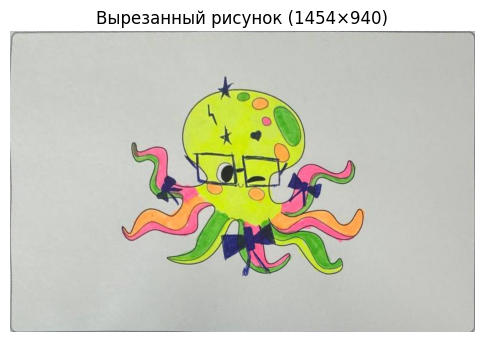

In [82]:
extracted = extract_colored(aligned, meta)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(extracted["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
rgba = extracted["rgba"]
plt.title(f"Вырезанный рисунок ({rgba.shape[1]}×{rgba.shape[0]})")
plt.show()

Бумага BGR: [193 198 196]
Gain BGR:   [1.244 1.212 1.224]


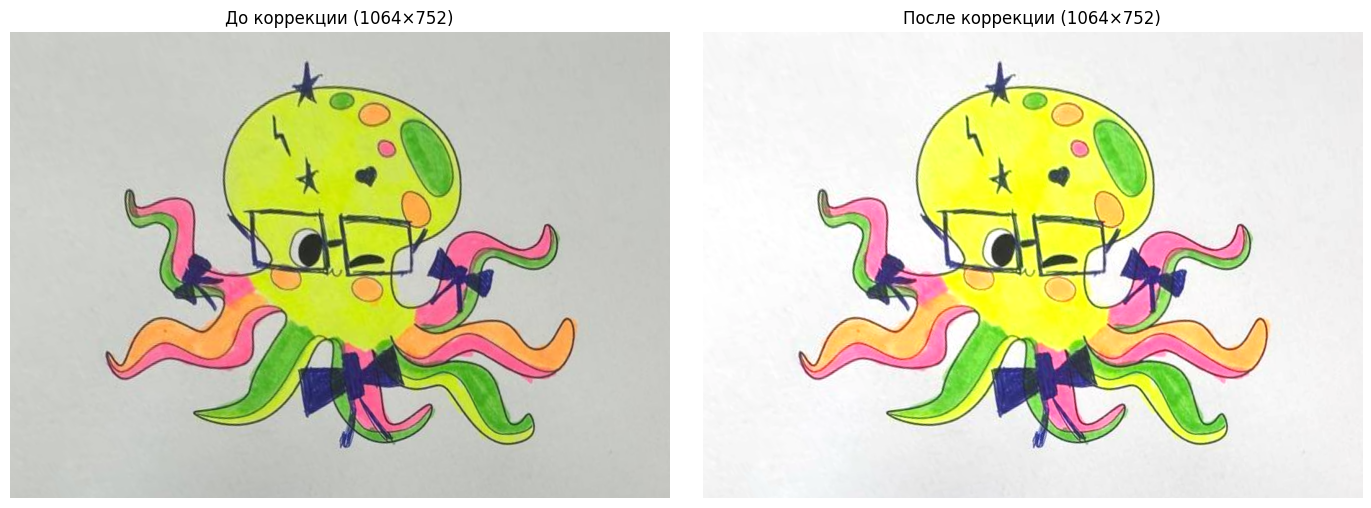

In [83]:
# Коррекция цвета: бумага = поля вокруг персонажа (между drawing_bbox и image_rect)
# Медиана цвета бумаги → поканальный gain = white_target / paper_median, клип gain_range

aligned_corrected, info = correct_photo(aligned, image_rect, meta, white_target=240, gain_range=(0.9, 1.3))
print(f"Бумага BGR: {info['paper_bgr'].astype(int)}")
print(f"Gain BGR:   {info['gain_bgr'].round(3)}")

ix, iy, iw, ih = image_rect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (img, title) in zip(axes, [
    (aligned[iy:iy+ih, ix:ix+iw], "До коррекции"),
    (aligned_corrected[iy:iy+ih, ix:ix+iw], "После коррекции"),
]):
    h, w = img.shape[:2]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title} ({w}×{h})")
    ax.axis("off")
plt.tight_layout(); plt.show()

In [84]:
# Сохраняем кроп drawing_bbox для RnD сегментации
x, y, w, h = meta["drawing_bbox"]
crop = aligned_corrected[y:y+h, x:x+w]

out = f"../rnd/input/seg_{CHAR_ID}_test4.png"
Path(out).parent.mkdir(exist_ok=True)
cv2.imwrite(out, crop)
print(f"Сохранено: {out} ({crop.shape[1]}×{crop.shape[0]})")

Сохранено: ../rnd/input/seg_003_test4.png (1454×940)


## Шаг 4. Перенос цветов на шаблон

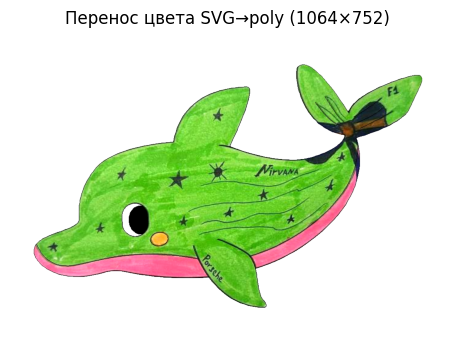

In [167]:
SVG_PATH = f"templates/{CHAR_ID}/mask.svg"

colored = transfer_color(aligned_corrected, SVG_PATH, image_rect)

rgba = colored["rgba"]
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(rgba, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title(f"Перенос цвета SVG→poly ({rgba.shape[1]}×{rgba.shape[0]})")
plt.show()

In [168]:
cv2.imwrite(f"output/{CHAR_ID}_colored.png", colored["rgba"])

True

Фото (среднее в зоне заливки): [ 63.77474403 180.73064169 118.81371078]
Результат (среднее в зоне заливки): [ 62.58732925 178.66143425 117.07623912]


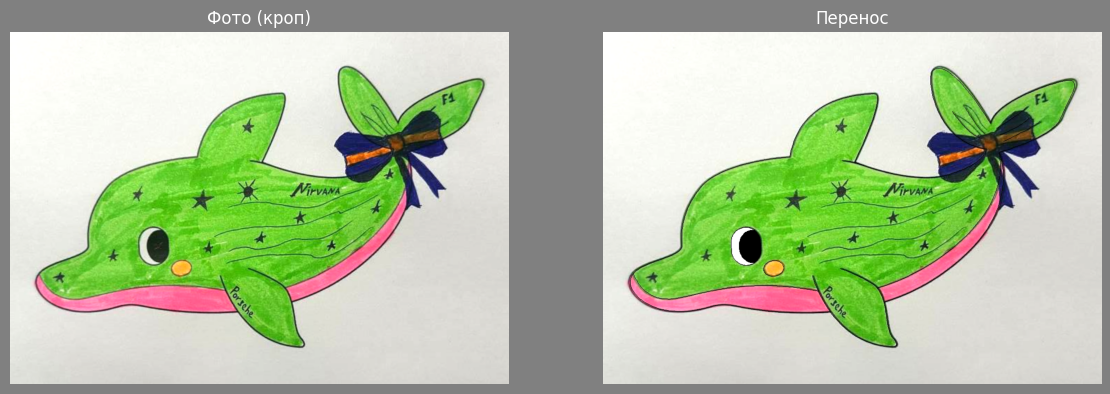

In [163]:
# Проверка: пиксели в зоне заливки должны совпадать
ix, iy, iw, ih = image_rect
photo_crop = aligned_corrected[iy:iy+ih, ix:ix+iw]
is_fill = colored["is_fill"]
print(f"Фото (среднее в зоне заливки): {photo_crop[is_fill].mean(axis=0)}")
print(f"Результат (среднее в зоне заливки): {colored['result'][is_fill].mean(axis=0)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='0.5')
for ax, (img, title) in zip(axes, [
    (photo_crop, "Фото (кроп)"),
    (colored["result"], "Перенос"),
]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, color='white')
    ax.set_facecolor('0.5')
    ax.axis("off")
plt.tight_layout(); plt.show()


### Пробуем сохранить примыкающие объекты

In [164]:
# если rembg еще не стоит:
# !pip install rembg onnxruntime

import cv2
import numpy as np
from rembg import remove

# photo_crop уже есть в твоем ноутбуке (вырезка aligned[iy:iy+ih, ix:ix+iw])
# mask уже есть (resize до iw, ih)

# 1) AI-удаление фона -> alpha маска объекта (кит + бантик)
ok, buf = cv2.imencode(".png", photo_crop)
fg_png = remove(buf.tobytes())  # bytes PNG RGBA
fg = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)
fg_alpha = fg[:, :, 3] > 32

# 2) Чистим мелкий мусор
k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
fg_alpha = cv2.morphologyEx(fg_alpha.astype(np.uint8), cv2.MORPH_OPEN, k3, iterations=1).astype(bool)

# 3) Твоя шаблонная маска кита
contour = mask < 50
fill_core = mask > 200

# 4) "Экстра" часть (бантик) = foreground вне шаблона, но рядом с китом
near = cv2.dilate((contour | fill_core).astype(np.uint8), np.ones((35, 35), np.uint8), iterations=1).astype(bool)
fill_extra = fg_alpha & (~fill_core) & near

# 5) Финальная заливка
fill = fill_core | fill_extra
between = (~contour) & (~fill)

# 6) (опционально) твой антишум цвета
clean = cv2.fastNlMeansDenoisingColored(photo_crop, None, 8, 8, 7, 21)
lab = cv2.cvtColor(clean, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab)
A = cv2.GaussianBlur(A, (0, 0), 3.0)
B = cv2.GaussianBlur(B, (0, 0), 3.0)
flat = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2BGR)

# 7) Сборка результата
result = np.zeros((ih, iw, 4), dtype=np.uint8)
result[between] = [255, 255, 255, 255]      # фон
result[contour] = [0, 0, 0, 255]            # контур
result[fill, :3] = flat[fill]               # цвет
result[fill, 3] = 255

# если хочешь, чтобы бантик был "поверх" линий:
result[fill_extra, :3] = flat[fill_extra]
result[fill_extra, 3] = 255

plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGRA2RGBA))
plt.title("Перенос цвета (с AI-маской бантика)")
plt.axis("off")
plt.show()


NameError: name 'mask' is not defined

## Шаг 5. Скелет + триангуляция

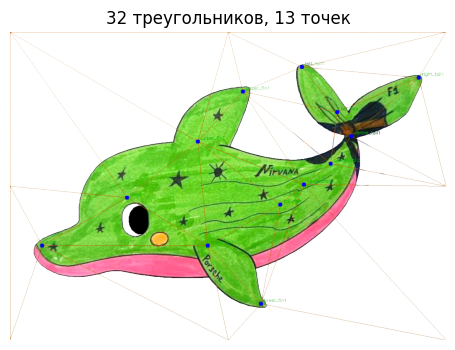

In [169]:
with open(TEMPLATE_SKELETON_PATH, encoding="utf-8") as f:
    keypoints = json.load(f)["keypoints"]

th, tw = colored["rgba"].shape[:2]
ctrl_pts, tri, n_kp, names = build_triangulation(keypoints, tw, th)

vis = draw_triangulation(colored["rgba"], ctrl_pts, tri, n_kp, names)

plt.figure(figsize=(6, 4))
plt.imshow(vis)  # уже RGBA, без конвертации
plt.axis("off")
plt.title(f"{len(tri.simplices)} треугольников, {n_kp} точек")
plt.show()

## Шаг 6. Анимация

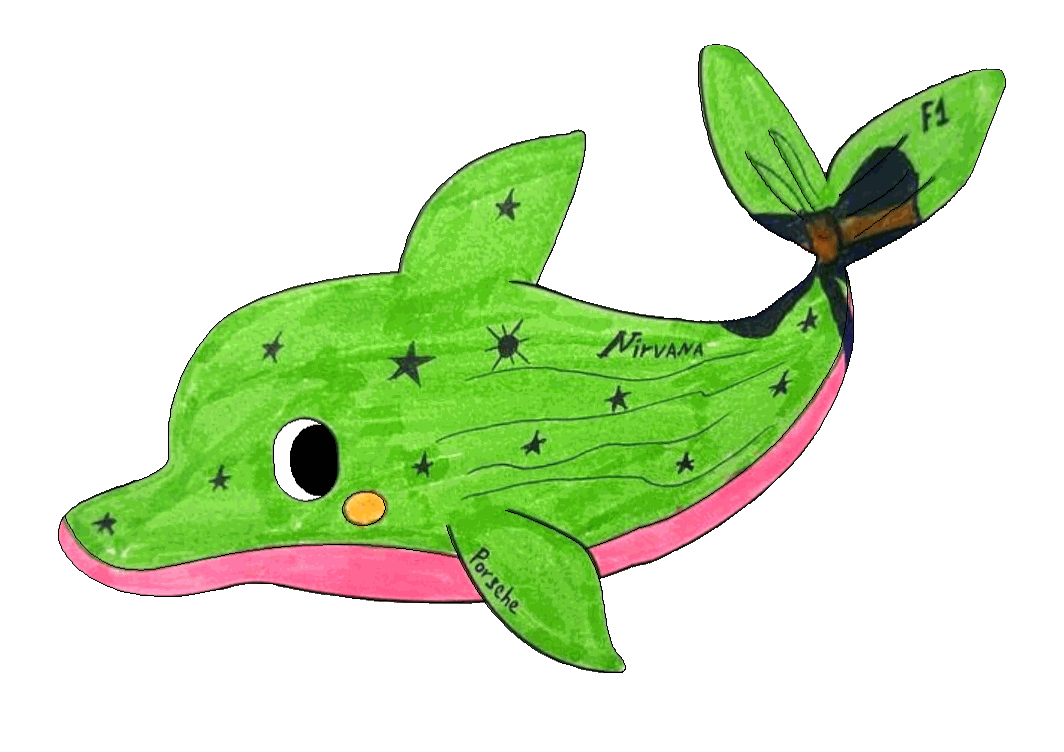

In [170]:
from IPython.display import Image as IPImage, display

# загружаем motion config
with open(MOTION_PATH, encoding="utf-8") as f:
    motion_cfg = json.load(f)

# анимируем (colored["rgba"] из предыдущей ячейки)
frames = animate_character(colored["rgba"], keypoints, motion_cfg)

# сохраняем GIF
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
gif_path = f"output/{CHAR_ID}_anim.gif"
pil_frames[0].save(gif_path, save_all=True, append_images=pil_frames[1:],
                   duration=1000 // 15, loop=0, disposal=2)
display(IPImage(filename=gif_path, width=500))